In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ✅")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Libraries loaded ✅
Pandas: 2.2.2
NumPy: 1.26.4


In [3]:
# Load all datasets
orders = pd.read_csv('../data/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

print("All datasets loaded ✅")
print(f"Orders: {orders.shape}")
print(f"Customers: {customers.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Order Payments: {order_payments.shape}")
print(f"Order Reviews: {order_reviews.shape}")
print(f"Products: {products.shape}")
print(f"Sellers: {sellers.shape}")
print(f"Category Translation: {category_translation.shape}")

All datasets loaded ✅
Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [4]:
# Explore the orders table — the backbone of this dataset
print("=== ORDERS TABLE ===")
print("\n-- First 5 rows --")
print(orders.head())

print("\n-- Column names and data types --")
print(orders.dtypes)

print("\n-- Missing values per column --")
print(orders.isnull().sum())

print("\n-- Order status breakdown --")
print(orders['order_status'].value_counts())

=== ORDERS TABLE ===

-- First 5 rows --
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1      

In [5]:
# Convert all date columns from text (object) to proper datetime format
# This is essential before any time-based analysis

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Verify the conversion worked
print("-- Data types AFTER conversion --")
print(orders.dtypes)

print("\n-- Date range of orders --")
print(f"Earliest order: {orders['order_purchase_timestamp'].min()}")
print(f"Latest order:   {orders['order_purchase_timestamp'].max()}")
print(f"Total date span: {(orders['order_purchase_timestamp'].max() - orders['order_purchase_timestamp'].min()).days} days")

-- Data types AFTER conversion --
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

-- Date range of orders --
Earliest order: 2016-09-04 21:15:19
Latest order:   2018-10-17 17:30:18
Total date span: 772 days


In [6]:
# Filter to delivered orders only
# Why: only delivered orders have complete data — purchase date, 
# delivery date, and actual revenue. All other statuses are incomplete.

delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f"Total orders:     {len(orders):,}")
print(f"Delivered orders: {len(delivered):,}")
print(f"Percentage:       {len(delivered)/len(orders)*100:.1f}%")

# Add useful time columns we'll need for analysis
# Why: extracting these now means we don't repeat this calculation later

delivered['order_year'] = delivered['order_purchase_timestamp'].dt.year
delivered['order_month'] = delivered['order_purchase_timestamp'].dt.month
delivered['order_year_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')

# Calculate delivery time in days
# Why: this is a key business metric — how fast is Olist delivering?
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - 
    delivered['order_purchase_timestamp']
).dt.days

print(f"\n-- Delivery time stats (days) --")
print(f"Average delivery: {delivered['delivery_days'].mean():.1f} days")
print(f"Fastest delivery: {delivered['delivery_days'].min()} days")
print(f"Slowest delivery: {delivered['delivery_days'].max()} days")
print(f"Median delivery:  {delivered['delivery_days'].median():.1f} days")

Total orders:     99,441
Delivered orders: 96,478
Percentage:       97.0%

-- Delivery time stats (days) --
Average delivery: 12.1 days
Fastest delivery: 0.0 days
Slowest delivery: 209.0 days
Median delivery:  10.0 days


In [7]:
# Join orders with order_items to get revenue
# Why order_items and not orders?
# Because the orders table has NO price column.
# Revenue (price) lives in order_items — one row per product purchased.

delivered_items = delivered.merge(
    order_items[['order_id', 'price', 'freight_value']],
    on='order_id',
    how='inner'
)

# Calculate total revenue per order
# price = product price, freight_value = shipping cost
# Together they represent total customer spend
delivered_items['total_revenue'] = delivered_items['price'] + delivered_items['freight_value']

# Group by year-month to get monthly revenue
monthly_revenue = (
    delivered_items.groupby('order_year_month')['total_revenue']
    .sum()
    .reset_index()
)

monthly_revenue.columns = ['year_month', 'revenue']
monthly_revenue['revenue'] = monthly_revenue['revenue'].round(2)

print("-- Monthly Revenue (first 10 rows) --")
print(monthly_revenue.head(10))
print(f"\nTotal revenue across all orders: R$ {delivered_items['total_revenue'].sum():,.2f}")
print(f"Average order value: R$ {delivered_items.groupby('order_id')['total_revenue'].sum().mean():,.2f}")
print(f"Total months of data: {len(monthly_revenue)}")

-- Monthly Revenue (first 10 rows) --
  year_month    revenue
0    2016-09     143.46
1    2016-10   46490.66
2    2016-12      19.62
3    2017-01  127482.37
4    2017-02  271239.32
5    2017-03  414330.95
6    2017-04  390812.40
7    2017-05  566851.40
8    2017-06  490050.37
9    2017-07  566299.08

Total revenue across all orders: R$ 15,419,773.75
Average order value: R$ 159.83
Total months of data: 23


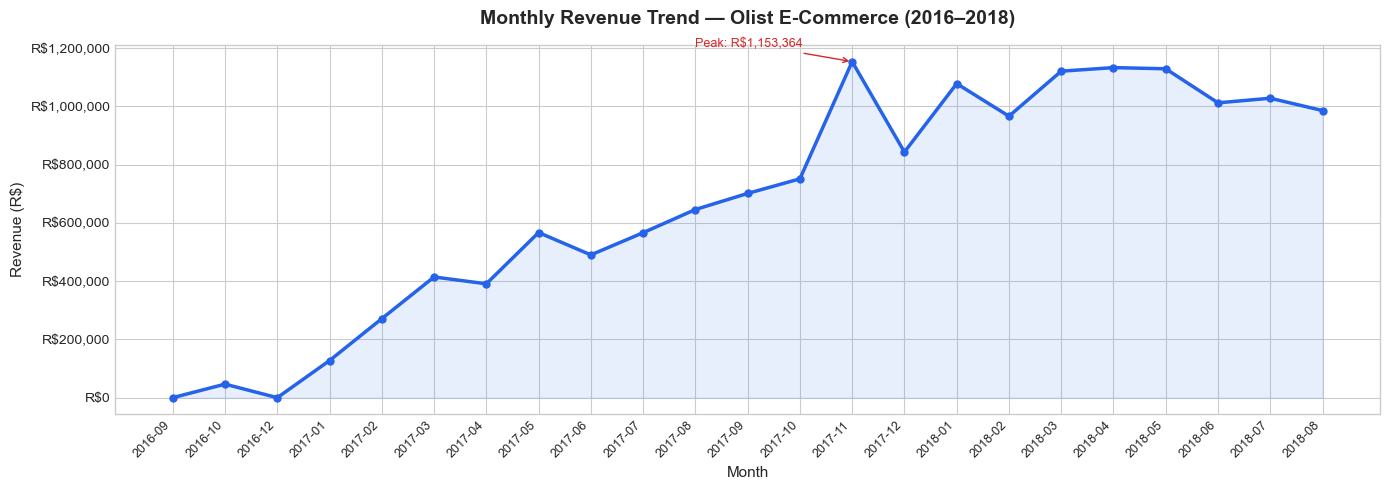

Chart saved to dashboard folder ✅


In [8]:
# Convert year_month to string for clean plotting
# Why: matplotlib can't directly plot Pandas Period objects cleanly
monthly_revenue['year_month_str'] = monthly_revenue['year_month'].astype(str)

# Set the visual style
# Why seaborn style: it looks more professional than default matplotlib
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure
# Why figsize=(14,5): wide enough to show all 23 months without crowding
fig, ax = plt.subplots(figsize=(14, 5))

# Plot the line
ax.plot(
    monthly_revenue['year_month_str'],
    monthly_revenue['revenue'],
    color='#2563EB',      # professional blue
    linewidth=2.5,
    marker='o',           # dot on each data point
    markersize=5
)

# Fill area under the line — makes trend easier to read visually
ax.fill_between(
    monthly_revenue['year_month_str'],
    monthly_revenue['revenue'],
    alpha=0.1,            # 10% opacity — subtle, not distracting
    color='#2563EB'
)

# Labels and title
ax.set_title('Monthly Revenue Trend — Olist E-Commerce (2016–2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (R$)', fontsize=11)

# Format Y axis to show numbers with commas (R$500,000 not R$500000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R${x:,.0f}'))

# Rotate x-axis labels so months don't overlap
plt.xticks(rotation=45, ha='right', fontsize=9)

# Add annotation for the peak month
peak_idx = monthly_revenue['revenue'].idxmax()
peak_month = monthly_revenue.loc[peak_idx, 'year_month_str']
peak_val = monthly_revenue.loc[peak_idx, 'revenue']

ax.annotate(
    f'Peak: R${peak_val:,.0f}',
    xy=(peak_idx, peak_val),
    xytext=(peak_idx - 3, peak_val + 50000),
    arrowprops=dict(arrowstyle='->', color='#DC2626'),
    fontsize=9,
    color='#DC2626'
)

plt.tight_layout()
plt.savefig('../dashboard/monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to dashboard folder ✅")

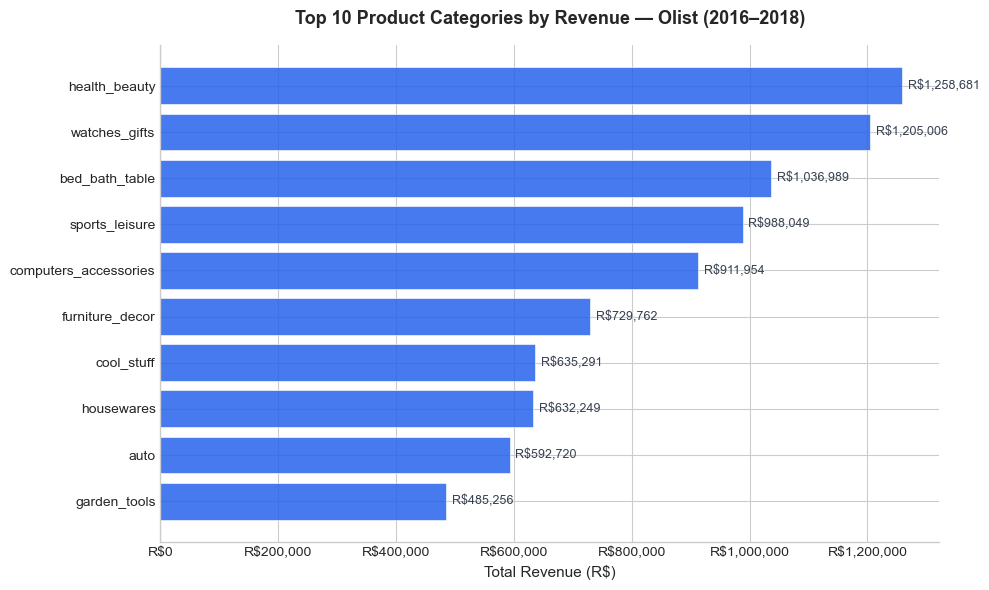

Chart saved ✅

-- Top 10 Categories --
             category    revenue
        health_beauty 1258681.34
        watches_gifts 1205005.68
       bed_bath_table 1036988.68
       sports_leisure  988048.97
computers_accessories  911954.32
      furniture_decor  729762.49
           cool_stuff  635290.85
           housewares  632248.66
                 auto  592720.11
         garden_tools  485256.46


In [9]:
# Merge order_items with products to get category names
# Then merge with translation to get English category names
# Why English: your portfolio audience is Canadian recruiters

items_products = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
).merge(
    category_translation,
    on='product_category_name',
    how='left'
)

# Calculate total revenue per category
# We use price only here (not freight) because freight isn't 
# a category-level business metric — it's a logistics cost
category_revenue = (
    items_products.groupby('product_category_name_english')['price']
    .sum()
    .reset_index()
    .sort_values('price', ascending=False)
    .head(10)
)

category_revenue.columns = ['category', 'revenue']
category_revenue['revenue'] = category_revenue['revenue'].round(2)

# Plot horizontal bar chart
# Why horizontal: category names are long — horizontal bars 
# give room for labels without rotating text
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    category_revenue['category'],
    category_revenue['revenue'],
    color='#2563EB',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels at end of each bar
for bar, val in zip(bars, category_revenue['revenue']):
    ax.text(
        bar.get_width() + 10000,
        bar.get_y() + bar.get_height()/2,
        f'R${val:,.0f}',
        va='center',
        fontsize=9,
        color='#374151'
    )

# Invert y-axis so highest revenue is at top
ax.invert_yaxis()

ax.set_title('Top 10 Product Categories by Revenue — Olist (2016–2018)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (R$)', fontsize=11)
ax.set_ylabel('')

# Format x-axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R${x:,.0f}'))

# Remove top and right borders — cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../dashboard/top_categories_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved ✅")
print("\n-- Top 10 Categories --")
print(category_revenue.to_string(index=False))

States with 100+ orders: 24

-- Top 5 Fastest States --
   state  avg_delivery_days  order_count
25    SP                8.3        40494
17    PR               11.5         4923
10    MG               11.5        11354
6     DF               12.5         2080
23    SC               14.5         3546

-- Top 5 Slowest States --
   state  avg_delivery_days  order_count
24    SE               21.0          335
9     MA               21.1          717
13    PA               23.3          946
1     AL               24.0          397
2     AM               26.0          145


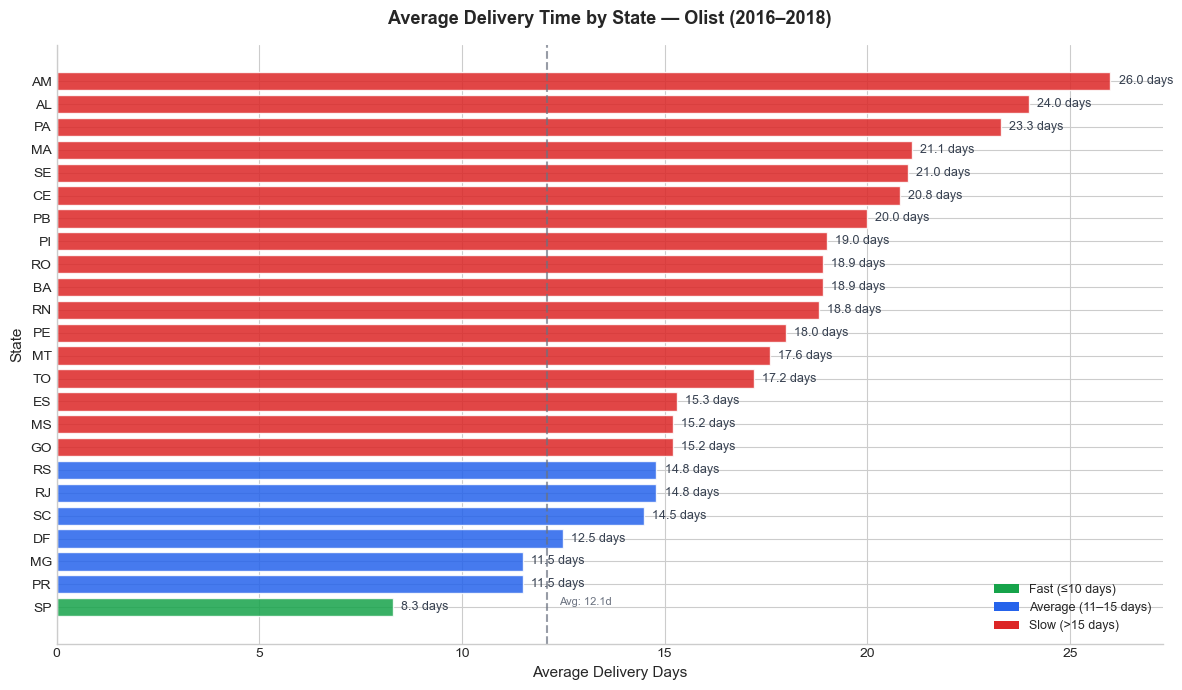


Chart saved ✅


In [10]:
# Merge delivered orders with customers to get state information
# Why: we want to know WHERE orders are going — 
# which Brazilian states have the best/worst delivery times

delivered_geo = delivered.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

# Calculate average delivery days per state
state_delivery = (
    delivered_geo.groupby('customer_state')['delivery_days']
    .agg(['mean', 'count'])
    .reset_index()
)

state_delivery.columns = ['state', 'avg_delivery_days', 'order_count']
state_delivery['avg_delivery_days'] = state_delivery['avg_delivery_days'].round(1)

# Filter to states with at least 100 orders
# Why: a state with 3 orders giving an average of 5 days 
# isn't statistically meaningful — it's noise, not insight
state_delivery = state_delivery[state_delivery['order_count'] >= 100]
state_delivery = state_delivery.sort_values('avg_delivery_days', ascending=True)

print(f"States with 100+ orders: {len(state_delivery)}")
print("\n-- Top 5 Fastest States --")
print(state_delivery.head())
print("\n-- Top 5 Slowest States --")
print(state_delivery.tail())

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Colour bars by speed — green for fast, red for slow
# Why: colour encoding adds a second information layer 
# without adding any extra elements
colors = []
for days in state_delivery['avg_delivery_days']:
    if days <= 10:
        colors.append('#16A34A')   # green — fast
    elif days <= 15:
        colors.append('#2563EB')   # blue — average
    else:
        colors.append('#DC2626')   # red — slow

bars = ax.barh(
    state_delivery['state'],
    state_delivery['avg_delivery_days'],
    color=colors,
    alpha=0.85,
    edgecolor='white'
)

# Add value labels
for bar, val in zip(bars, state_delivery['avg_delivery_days']):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{val} days',
        va='center',
        fontsize=9,
        color='#374151'
    )

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#16A34A', label='Fast (≤10 days)'),
    Patch(facecolor='#2563EB', label='Average (11–15 days)'),
    Patch(facecolor='#DC2626', label='Slow (>15 days)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_title('Average Delivery Time by State — Olist (2016–2018)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Average Delivery Days', fontsize=11)
ax.set_ylabel('State', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a vertical reference line at the overall average
overall_avg = delivered['delivery_days'].mean()
ax.axvline(x=overall_avg, color='#6B7280', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(overall_avg + 0.3, 0, f'Avg: {overall_avg:.1f}d',
        fontsize=8, color='#6B7280', va='bottom')

plt.tight_layout()
plt.savefig('../dashboard/delivery_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved ✅")

-- Review Score Distribution --
   score  count  percentage
0      1  11424        11.5
1      2   3151         3.2
2      3   8179         8.2
3      4  19142        19.3
4      5  57328        57.8

Average review score: 4.09 / 5.0

-- Average Review Score by Delivery Speed --
delivery_days
Fast\n(≤7 days)          4.41
Normal\n(8–14 days)      4.29
Slow\n(15–21 days)       4.10
Very Slow\n(>21 days)    3.01
Name: review_score, dtype: float64


/var/folders/gg/fjkgr0892fgbxlch85bykgfw0000gn/T/ipykernel_85607/1458064915.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_score_by_speed = delivered_reviews.groupby(


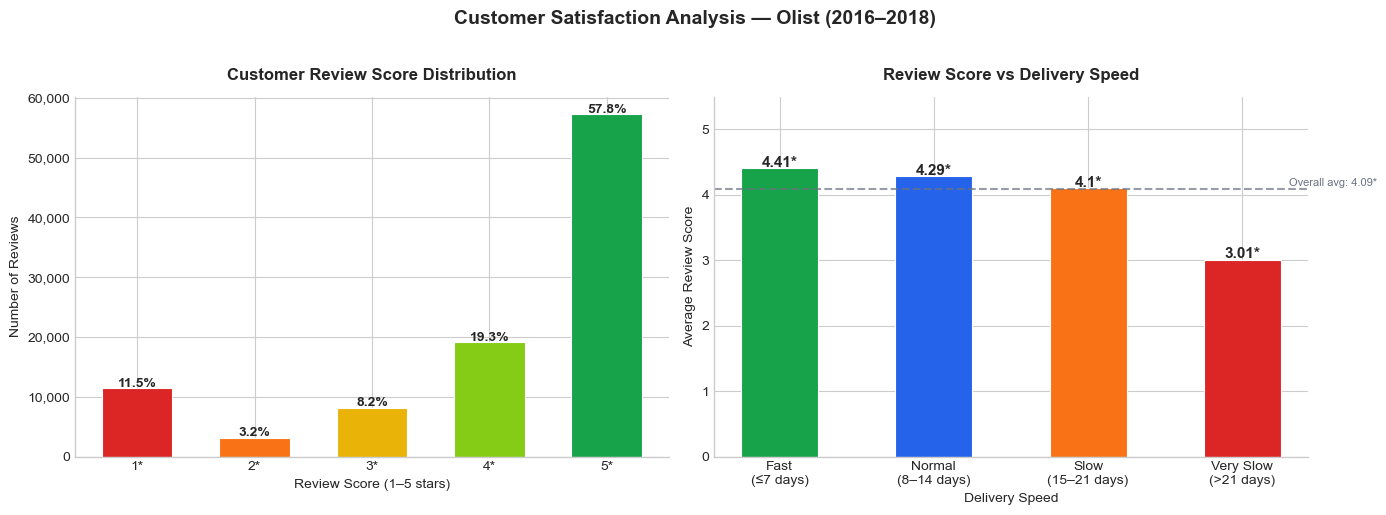


Chart saved ✅


In [12]:
# Chart 4: Customer Review Score Distribution
# Why this matters: review scores are the voice of the customer
# They tell you how satisfied people are AFTER the delivery experience
# Connecting delivery speed to satisfaction is a key business insight

review_score_dist = (
    order_reviews['review_score']
    .value_counts()
    .sort_index()
    .reset_index()
)
review_score_dist.columns = ['score', 'count']
review_score_dist['percentage'] = (
    review_score_dist['count'] / review_score_dist['count'].sum() * 100
).round(1)

print("-- Review Score Distribution --")
print(review_score_dist)
print(f"\nAverage review score: {order_reviews['review_score'].mean():.2f} / 5.0")

# Now connect delivery speed to review scores — the key insight
delivered_reviews = delivered.merge(
    order_reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

avg_score_by_speed = delivered_reviews.groupby(
    pd.cut(delivered_reviews['delivery_days'],
           bins=[0, 7, 14, 21, 999],
           labels=['Fast\n(≤7 days)', 'Normal\n(8–14 days)',
                   'Slow\n(15–21 days)', 'Very Slow\n(>21 days)'])
)['review_score'].mean().round(2)

print("\n-- Average Review Score by Delivery Speed --")
print(avg_score_by_speed)

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — review score distribution
colors_scores = ['#DC2626', '#F97316', '#EAB308', '#84CC16', '#16A34A']
bars1 = ax1.bar(
    review_score_dist['score'],
    review_score_dist['count'],
    color=colors_scores,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

for bar, pct in zip(bars1, review_score_dist['percentage']):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{pct}%',
        ha='center', fontsize=10, fontweight='bold'
    )

ax1.set_title('Customer Review Score Distribution', fontsize=12,
              fontweight='bold', pad=12)
ax1.set_xlabel('Review Score (1–5 stars)', fontsize=10)
ax1.set_ylabel('Number of Reviews', fontsize=10)
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['1*', '2*', '3*', '4*', '5*'])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right chart — delivery speed vs review score
colors_speed = ['#16A34A', '#2563EB', '#F97316', '#DC2626']
bars2 = ax2.bar(
    avg_score_by_speed.index,
    avg_score_by_speed.values,
    color=colors_speed,
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

for bar, val in zip(bars2, avg_score_by_speed.values):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val}*',
        ha='center', fontsize=11, fontweight='bold'
    )

ax2.set_title('Review Score vs Delivery Speed', fontsize=12,
              fontweight='bold', pad=12)
ax2.set_xlabel('Delivery Speed', fontsize=10)
ax2.set_ylabel('Average Review Score', fontsize=10)
ax2.set_ylim(0, 5.5)
ax2.axhline(y=order_reviews['review_score'].mean(),
            color='#6B7280', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.text(3.3, order_reviews['review_score'].mean() + 0.05,
         f'Overall avg: {order_reviews["review_score"].mean():.2f}*',
         fontsize=8, color='#6B7280')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Customer Satisfaction Analysis — Olist (2016–2018)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../dashboard/customer_satisfaction.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved ✅")

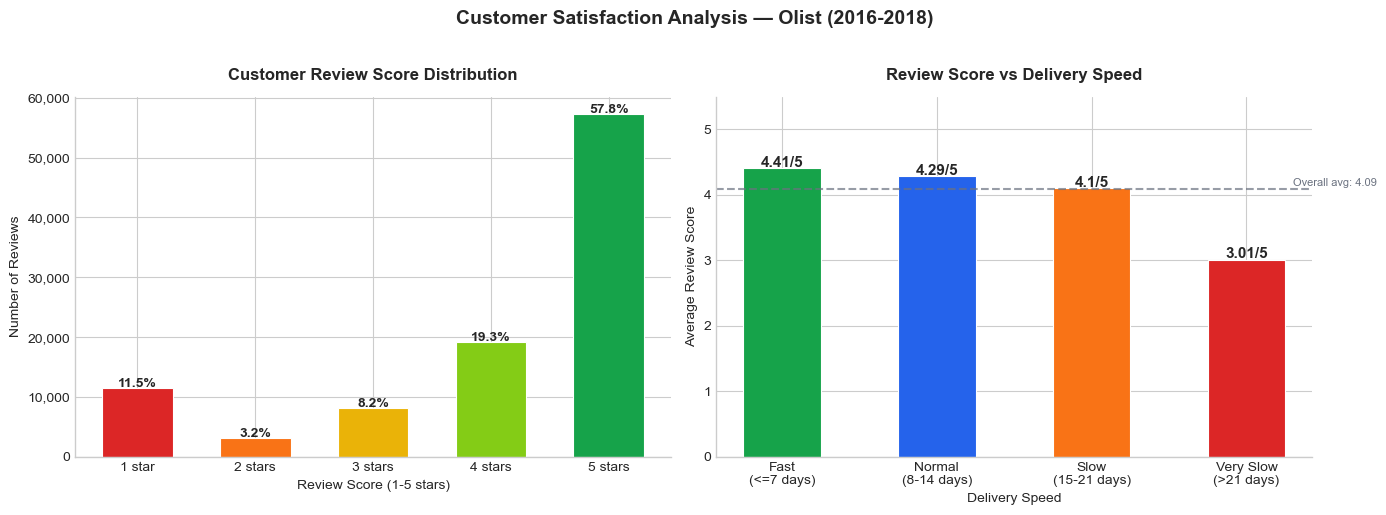

Chart saved cleanly with no warnings ✅


In [13]:
# Fix 1: Replace star symbol with text to avoid font warning
# Fix 2: Add observed=True to silence FutureWarning

avg_score_by_speed = delivered_reviews.groupby(
    pd.cut(delivered_reviews['delivery_days'],
           bins=[0, 7, 14, 21, 999],
           labels=['Fast\n(<=7 days)', 'Normal\n(8-14 days)',
                   'Slow\n(15-21 days)', 'Very Slow\n(>21 days)']),
    observed=True
)['review_score'].mean().round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — review score distribution (unchanged)
colors_scores = ['#DC2626', '#F97316', '#EAB308', '#84CC16', '#16A34A']
bars1 = ax1.bar(
    review_score_dist['score'],
    review_score_dist['count'],
    color=colors_scores,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

for bar, pct in zip(bars1, review_score_dist['percentage']):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{pct}%',
        ha='center', fontsize=10, fontweight='bold'
    )

ax1.set_title('Customer Review Score Distribution', fontsize=12,
              fontweight='bold', pad=12)
ax1.set_xlabel('Review Score (1-5 stars)', fontsize=10)
ax1.set_ylabel('Number of Reviews', fontsize=10)
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['1 star', '2 stars', '3 stars', '4 stars', '5 stars'])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right chart — delivery speed vs review score (fixed labels)
colors_speed = ['#16A34A', '#2563EB', '#F97316', '#DC2626']
bars2 = ax2.bar(
    avg_score_by_speed.index,
    avg_score_by_speed.values,
    color=colors_speed,
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

for bar, val in zip(bars2, avg_score_by_speed.values):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val}/5',
        ha='center', fontsize=11, fontweight='bold'
    )

ax2.set_title('Review Score vs Delivery Speed', fontsize=12,
              fontweight='bold', pad=12)
ax2.set_xlabel('Delivery Speed', fontsize=10)
ax2.set_ylabel('Average Review Score', fontsize=10)
ax2.set_ylim(0, 5.5)
ax2.axhline(y=order_reviews['review_score'].mean(),
            color='#6B7280', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.text(3.3, order_reviews['review_score'].mean() + 0.05,
         f'Overall avg: {order_reviews["review_score"].mean():.2f}',
         fontsize=8, color='#6B7280')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Customer Satisfaction Analysis — Olist (2016-2018)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../dashboard/customer_satisfaction.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved cleanly with no warnings ✅")

# Olist E-Commerce Analysis — Key Findings

**Dataset:** 99,441 orders | Sept 2016 – Oct 2018 | R$15.4M total revenue

---

## Finding 1: Revenue grew 6x in 2017 with a clear seasonal peak
Monthly revenue grew from R$127K in January 2017 to R$750K by October 2017.
November 2017 hit the peak at R$1.15M — driven by Black Friday/Cyber Monday.
Revenue plateaued around R$1.1M/month throughout 2018, signalling market maturity
in core regions.

**Business implication:** Olist should plan inventory and logistics capacity 
increases ahead of November each year to capitalise on the seasonal spike.

---

## Finding 2: 75% of Brazilian states experience above-average delivery times
São Paulo — home to most Olist sellers — achieves 8.3 days average delivery.
18 out of 24 states exceed the 15-day threshold, with Amazonas worst at 26 days.
The root cause is geographic: northern states have limited road infrastructure
and are far from seller hubs.

**Business implication:** Incentivising seller expansion in northern and 
northeastern states would reduce last-mile delivery distance and directly 
improve customer satisfaction in underserved regions.

---

## Finding 3: Delivery speed is the #1 driver of customer satisfaction
Orders delivered in 7 days or less average 4.41/5 stars.
Orders taking more than 21 days average only 3.01/5 stars — a 1.4 point drop.
57.8% of all reviews are 5 stars, but 11.5% are 1 star — showing a polarised
customer base where delivery experience is the deciding factor.

**Business implication:** Every day added to delivery time measurably reduces
satisfaction. Reducing average delivery time from 12 to 8 days across all states
could shift a significant portion of 1-star reviews to 4-5 stars.

---

## Tools Used
- Python (Pandas, NumPy, Matplotlib, Seaborn)
- MySQL — data validation queries
- Jupyter Notebook
- Tableau